<center><h1> TD N°2 : SVM non linéaire</h1></center>


## Import package

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import time
#Viz
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Modélisation 
#Classifier
from sklearn.svm import SVC 
from sklearn.linear_model import SGDClassifier , LogisticRegression
#Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#Eval
from sklearn.model_selection import cross_val_score ,learning_curve ,GridSearchCV
from sklearn_evaluation import plot


## Function

In [3]:
def plot_predictions(clf, axes):
    
    ''''
    Plot prediction permet de visualiser la frontière de décision d'un SVM avec kernel.
    Elle ne marche qu'avec 2 features (2 dimensions)
    
    IL FAUT également tracer votre X_train avant de faire cette fonction!!
    
    '''
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)
    

#clf = model SVC
#axes = [xlim_min, xlim_max, ylim_min, ylim_max]

## Enoncé TD

#### Exploration and data analysis (EDA)

1) Importer le jeu de données breast cancer disponible dans le module sklearn.datasets<br>
2) Analyser le dataset avec des statistiques descriptives<br>
3) Recoder les variables si nécessaire<br>
4) Faites une première étape de feature selection avec votre analyse statistique<br> 

#### Modélisation binaire

5) Importer les modèles suivants **SGDClassifier, SVC, LogisticRegression**<br>
6) Regarder l'effet du changement de noyau pour la fonction **SVC**<br>
- 6.1) Garder uniquement 2 features pour cette partie<br>
- 6.2) Utiliser la fonction **plot_predictions** pour voir la fonction de décision en fonction du noyau<br>
- 6.3) Varier les autres hyperparamètres en plus du **kernel**<br>

7) Lancer vos modèles sur les features que vous avez gardés avec vos statistiques descriptives( pour **SVC** utiliser plusieurs noyaux)<br>
8) Réaliser une cross-validation afin de déterminer des modèles prometteurs. Ne pas tuner les hyperparamètres<br>
9) Analyser vos résultats (metrics, erreurs de prédictions, ...)<br>
10) Tuner pour obtenir le meilleur modèle et réaliser une prédiction<br>
- 10.1) Analyser les variables importantes de votre modèle



## Description du dataset



<img src="https://www.researchgate.net/profile/Faiza-Khattak/publication/281099329/figure/fig3/AS:284623327252504@1444870897714/Example-images-of-the-breast-cancer-dataset-From-left-to-right-First-three-are.png" alt="image_breast_cancer.png" style="width:800px;"/>
</p>

Le data set breast cancer contient des informations sur la caractéristiques de tumeur bénine ou non.<br>
Les informations sont issues d'images  (exmple ci-dessus) et un docteur à labélisé si la tumeur était bénine ou maligne.

##### Info du dataset

Attribute Information:
- radius (mean of distances from center to points on the perimeter)
- texture (standard deviation of gray-scale values)
- perimeter
- area
- smoothness (local variation in radius lengths)
- compactness (perimeter^2 / area - 1.0)
- concavity (severity of concave portions of the contour)
- concave points (number of concave portions of the contour)
- symmetry
- fractal dimension ("coastline approximation" - 1)
        
Chaque attribut possède 3 informations. La moyenne(mean), l'écart type(standart error) et le maximun("worst")


## Code

## Exploration and data analysis


#### 1) Importer le jeu de données breast cancer disponible dans le module sklearn.datasets

In [4]:
#Load dataset breast cancer
data = load_breast_cancer()

In [5]:
# visualisation des données
data_df = pd.DataFrame(data.data, columns=data.feature_names)
data_df['target'] = data.target
print(data_df.head())
print(data_df['target'].value_counts())



   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

##### 2) Analyser le dataset avec des statistiques descriptives

- Statistiques univariées
- Statistiques bivariées
- Statistiques multivariées (si vous avez le temps)

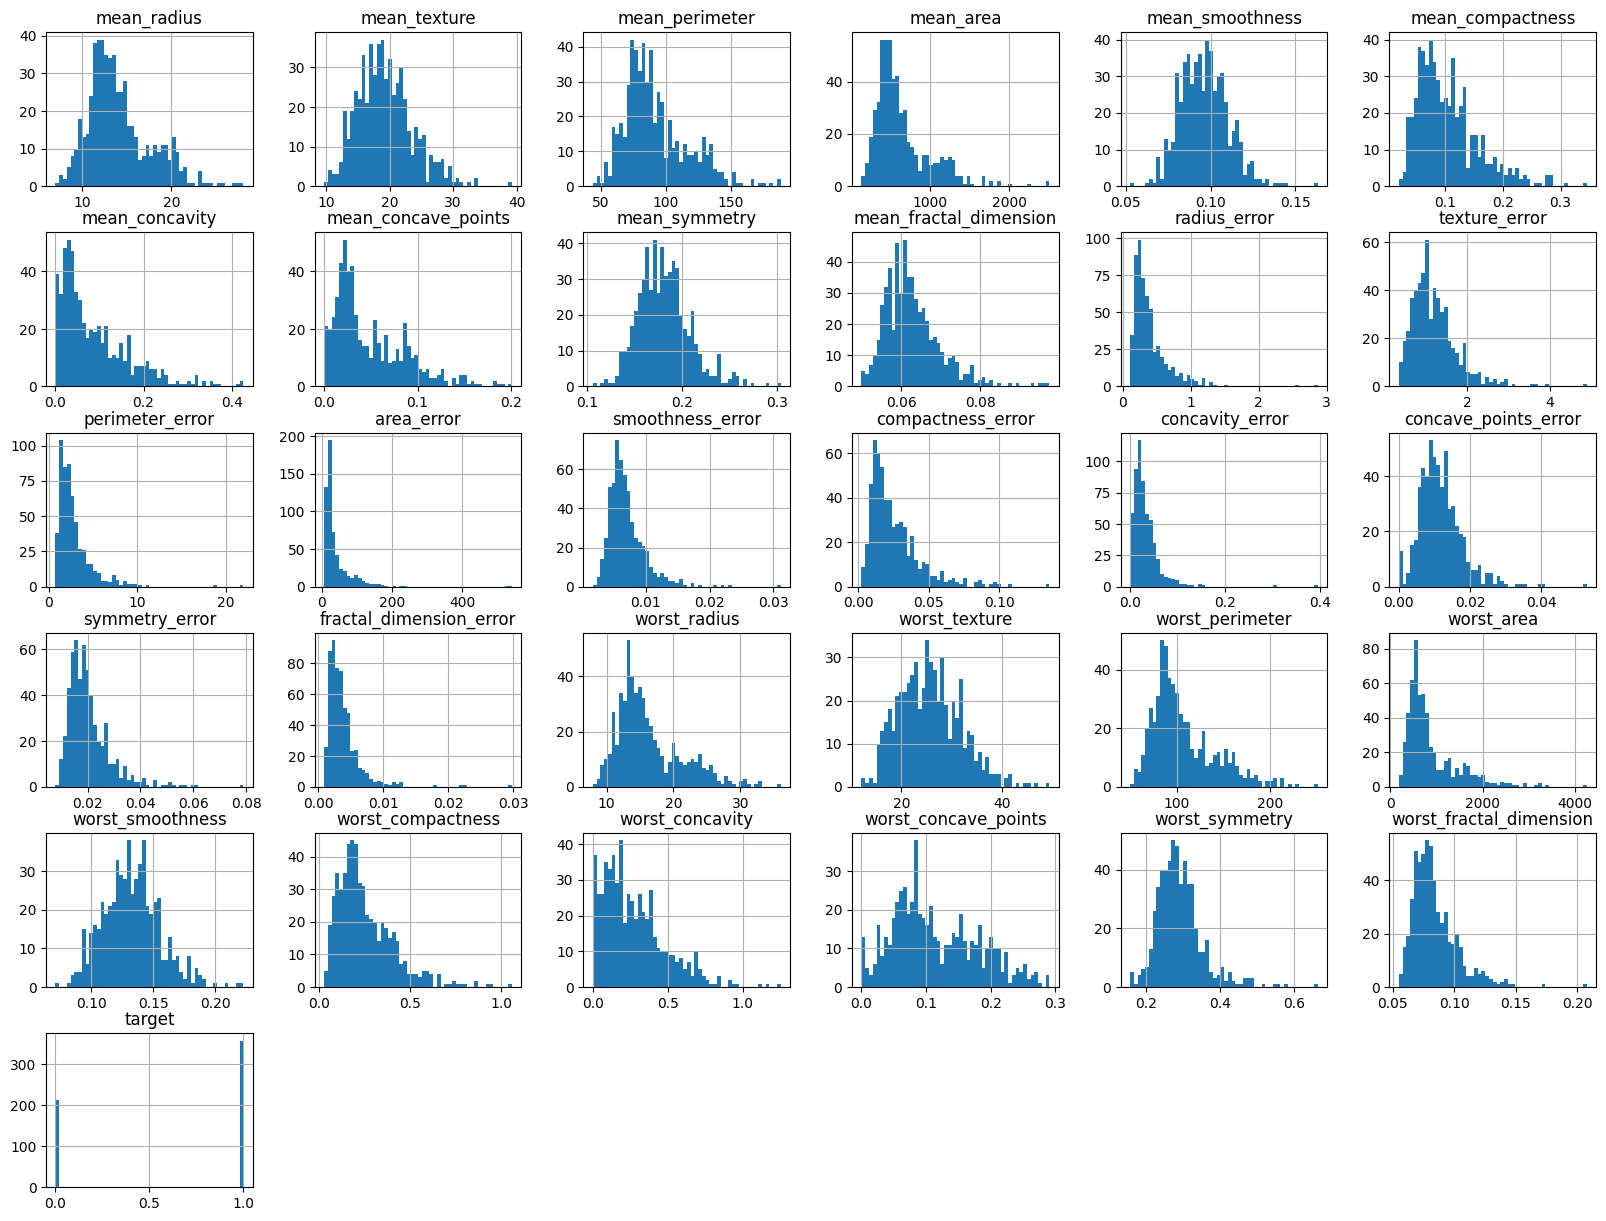

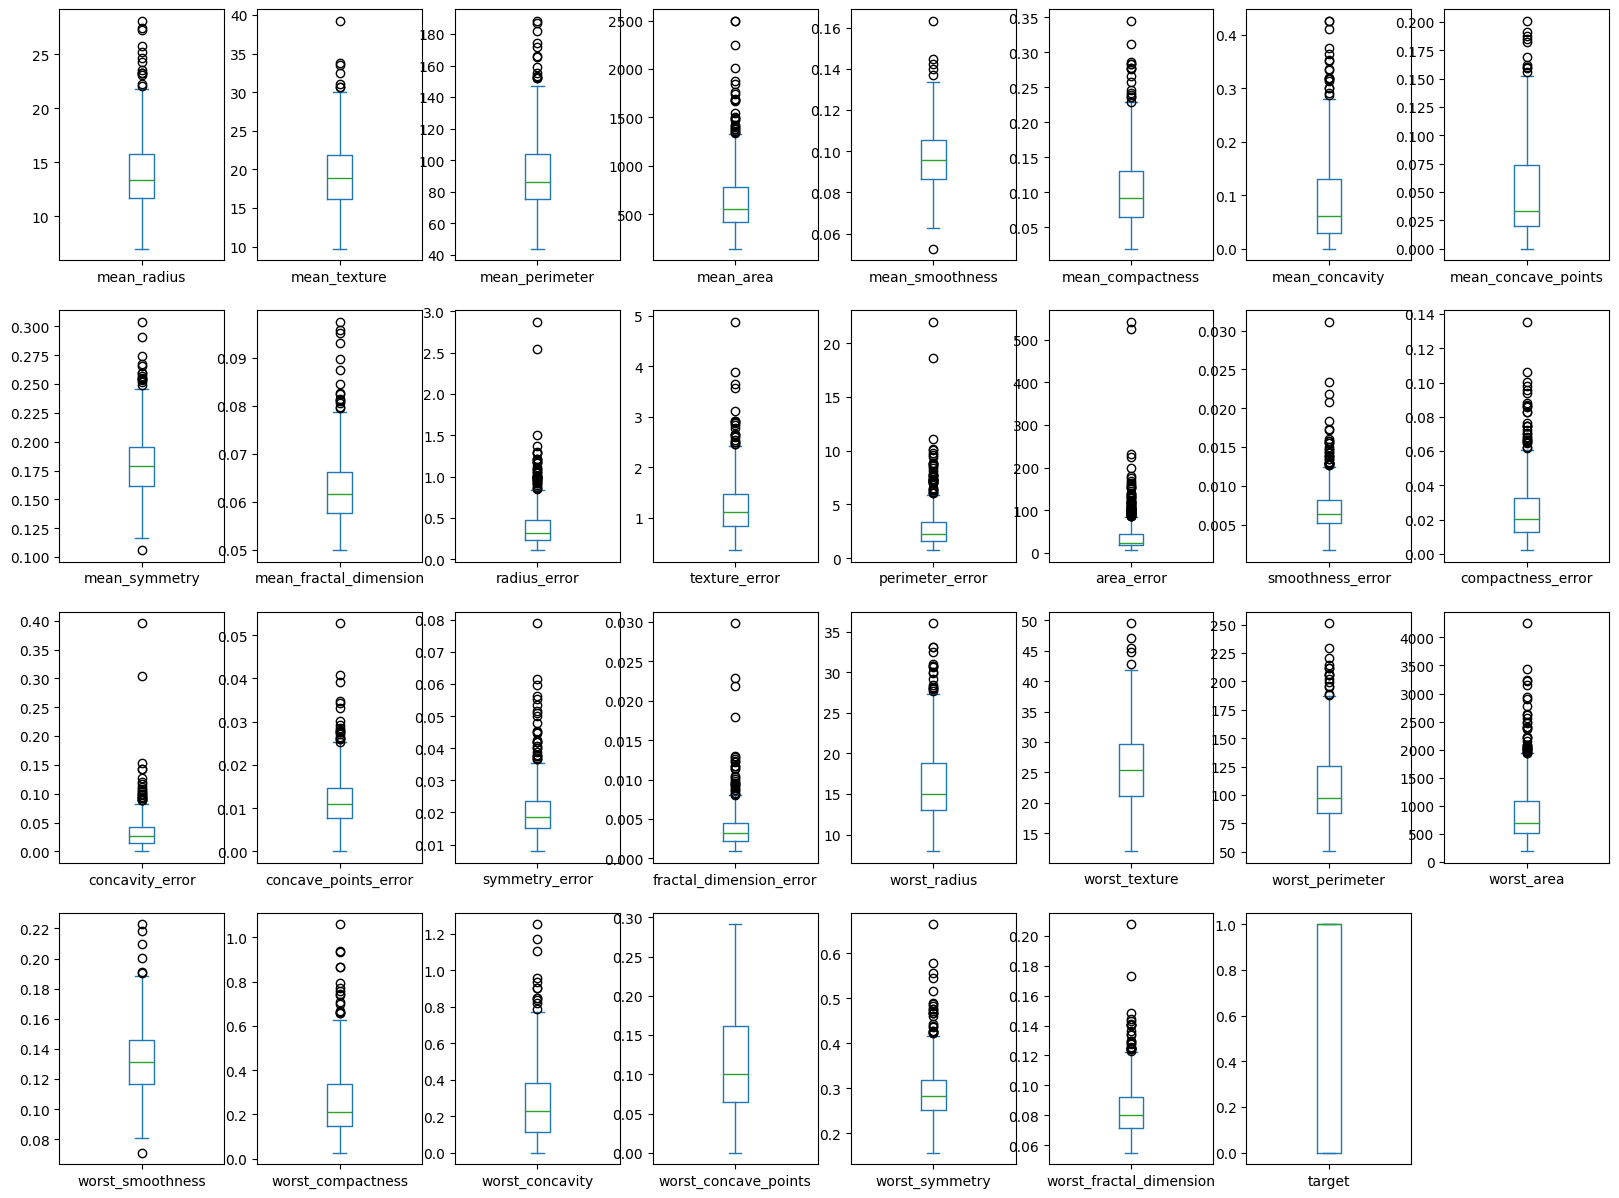

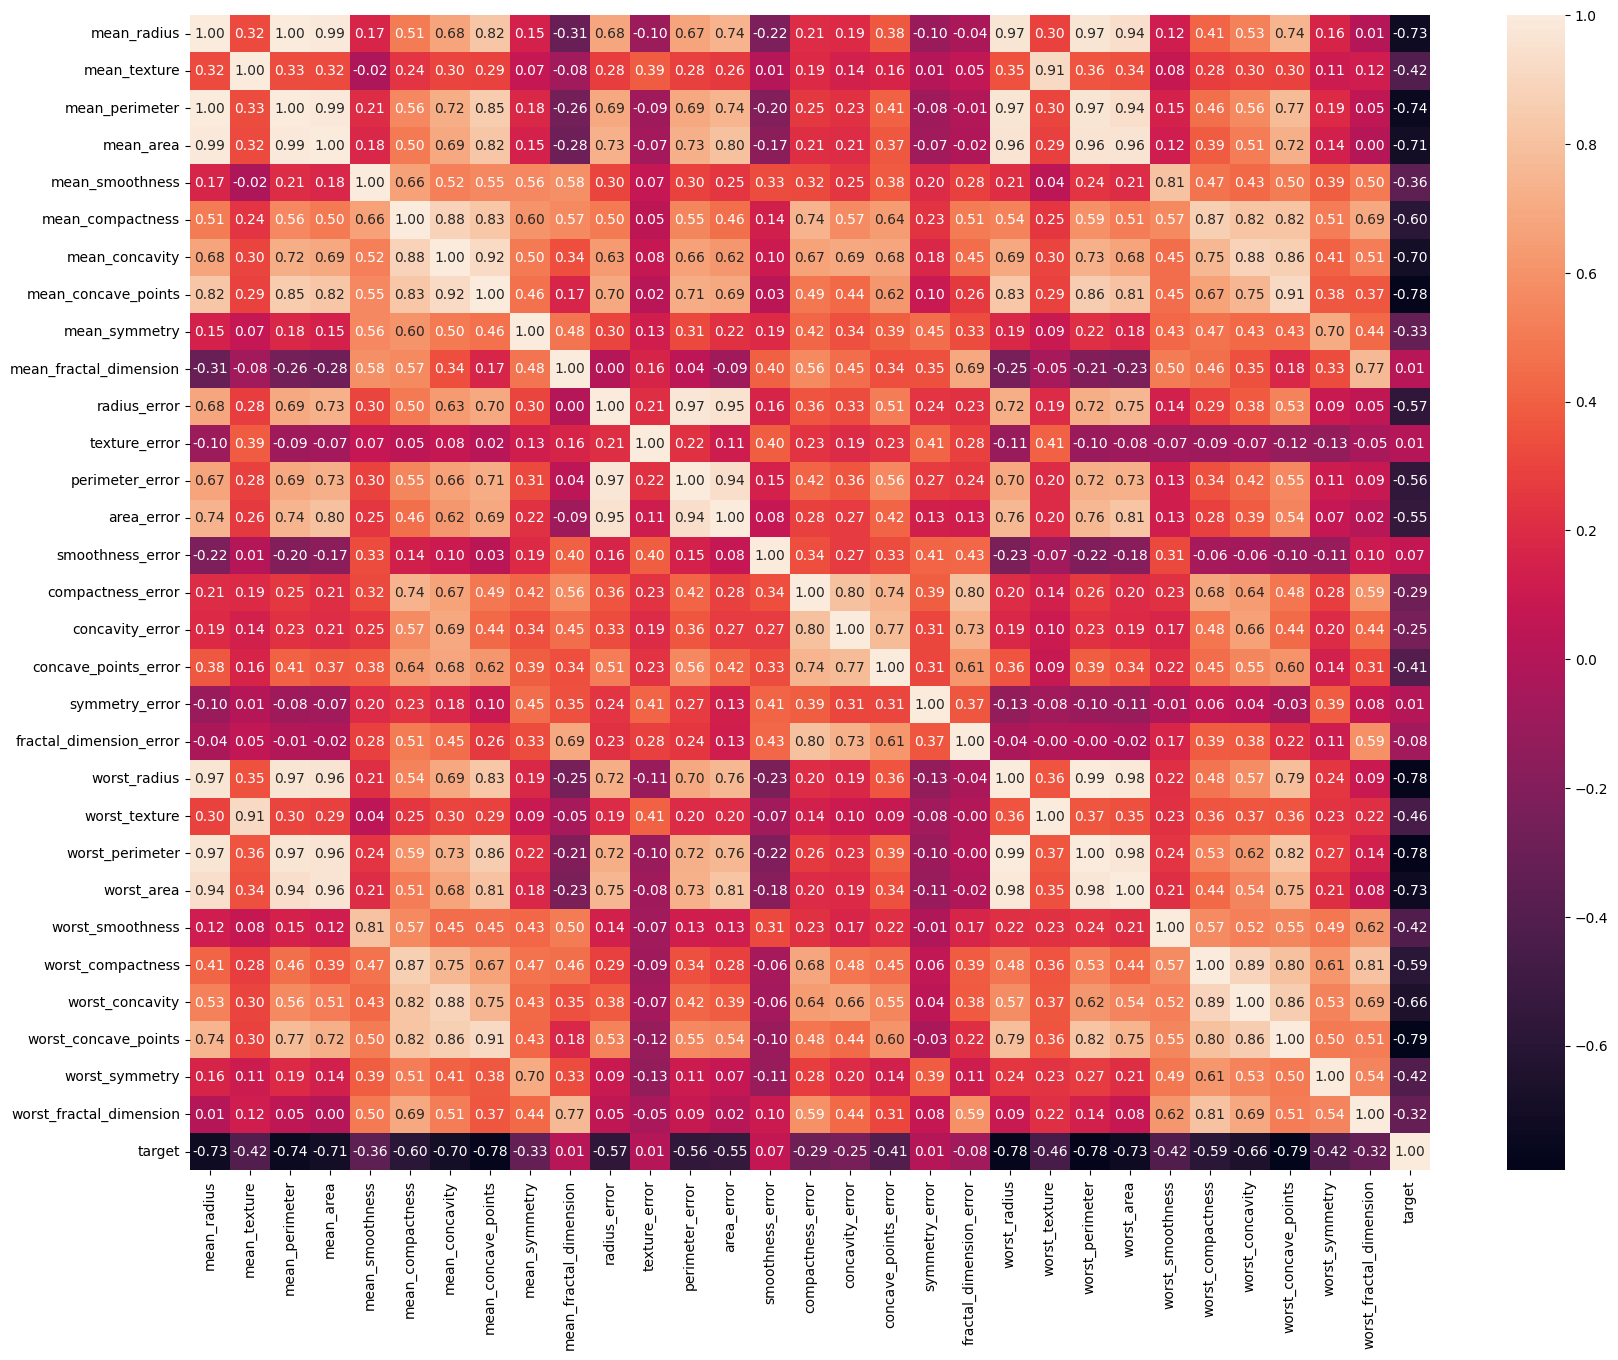

mean_radius                0
mean_texture               0
mean_perimeter             0
mean_area                  0
mean_smoothness            0
mean_compactness           0
mean_concavity             0
mean_concave_points        0
mean_symmetry              0
mean_fractal_dimension     0
radius_error               0
texture_error              0
perimeter_error            0
area_error                 0
smoothness_error           0
compactness_error          0
concavity_error            0
concave_points_error       0
symmetry_error             0
fractal_dimension_error    0
worst_radius               0
worst_texture              0
worst_perimeter            0
worst_area                 0
worst_smoothness           0
worst_compactness          0
worst_concavity            0
worst_concave_points       0
worst_symmetry             0
worst_fractal_dimension    0
target                     0
dtype: int64


In [9]:
#statistiques descriptives univariées
data_df.describe()
#histogramme
data_df.hist(bins=50, figsize=(20,15))
plt.show()
#boxplot
data_df.plot(kind='box', subplots=True, layout=(4,8), figsize=(20,15))
plt.show()
#Matrice de corrélation
corr_matrix = data_df.corr()
plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.show()

# voir les valeurs manquantes
print(data_df.isnull().sum())


#### 3) Recoder les variables si nécessaire


In [7]:
# on recode les variables car elles sont trop cheum on met des "_"
data_df.columns = [col.replace(' ', '_').replace('(', '').replace(')', '') for col in data_df.columns]



In [8]:
# verification des colonnes 
print(data_df.columns)

Index(['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
       'mean_smoothness', 'mean_compactness', 'mean_concavity',
       'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension',
       'radius_error', 'texture_error', 'perimeter_error', 'area_error',
       'smoothness_error', 'compactness_error', 'concavity_error',
       'concave_points_error', 'symmetry_error', 'fractal_dimension_error',
       'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area',
       'worst_smoothness', 'worst_compactness', 'worst_concavity',
       'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension',
       'target'],
      dtype='object')


In [10]:
# recode la variabkle target le 0 ET 1 sont inversés
data_df['target'] = data_df['target'].map({0:1, 1:0})

#### 4) Faites une première étape de feature selection avec votre analyse des statistiques

In [13]:
# création des jeux de données d'entrainement et de test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_df.drop('target', axis=1), data_df['target'], test_size=0.2, random_state=42)


In [11]:
# les variables tres correélées entre elles peuvent poser problème pour le SVM
# feature qui  supprimme  une des deux variables dont la corrélation est > 0.8
def remove_highly_correlated_features(df, threshold=0.8):
    corr_matrix = df.corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    return df.drop(columns=to_drop), to_drop
data_df_reduced, dropped_features = remove_highly_correlated_features(data_df.drop('target', axis=1), threshold=0.8)
print(f"Features supprimées en raison de la forte corrélation : {dropped_features}")
data_df_reduced['target'] = data_df['target']
print(data_df_reduced.head())


# je crois que le feature selection doit se faire uniquement sur le train set pour éviter le data leakage

Features supprimées en raison de la forte corrélation : ['mean_perimeter', 'mean_area', 'mean_concavity', 'mean_concave_points', 'perimeter_error', 'area_error', 'concavity_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_fractal_dimension']
   mean_radius  mean_texture  mean_smoothness  mean_compactness  \
0        17.99         10.38          0.11840           0.27760   
1        20.57         17.77          0.08474           0.07864   
2        19.69         21.25          0.10960           0.15990   
3        11.42         20.38          0.14250           0.28390   
4        20.29         14.34          0.10030           0.13280   

   mean_symmetry  mean_fractal_dimension  radius_error  texture_error  \
0         0.2419                 0.07871        1.0950         0.9053   
1         0.1812                 0.05667        0.5435         0.7

In [14]:
# feature selection sur le train 
X_train_reduced, dropped_features = remove_highly_correlated_features(
    X_train, threshold=0.8
)

X_test_reduced = X_test.drop(columns=dropped_features)


In [15]:
# faire standzard scaler sur les données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled  = scaler.transform(X_test_reduced)


In [16]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_reduced.columns,
    index=X_train_reduced.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_reduced.columns,
    index=X_test_reduced.index
)


## Modélisation Binaire

#### 5) Importer les modèles suivants SGDClassifier, SVC, LogisticRegression

In [17]:
# importer les moèdeles SGDClassifier et SVC, LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier , LogisticRegression


#### 6) Regarder l'effet du changement de noyau pour la fonction SVC

6.1) Garder uniquement **2 features** pour cette partie<br>
6.2) Utiliser la fonction **plot_predictions** pour voir la fonction de décision en fonction du noyau<br>
6.3) Varier les autres hyperparamètres en plus du kernel<br>

In [30]:
X = data_df_reduced.drop(columns='target').iloc[:, :2]
y = data_df_reduced['target']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Initialize and train the SVC model
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_model.fit(X_train_scaled, y_train)


 # Evaluate the model's accuracy on the test set
y_pred = svc_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy du modèle SVC linéaire : {accuracy:.4f}")



Accuracy du modèle SVC linéaire : 0.9064


In [ ]:

# Create a mesh to plot the decision boundary
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Make predictions over the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVC with  kernel')
plt.show()
plt.scatter(X_train_scaled.iloc[:, 0], X_train_scaled.iloc[:, 1], c=y_train, cmap=plt.cm.brg, edgecolors='k')

clf = svc_model
axes = [X_train_scaled.iloc[:, 0].min()-1, X_train_scaled.iloc[:, 0].max()+1,
        X_train_scaled.iloc[:, 1].min()-1, X_train_scaled.iloc[:, 1].max()+1]


plot_predictions(clf, axes)
plt.xlabel(X_train_scaled.columns[0])
plt.ylabel(X_train_scaled.columns[1])
plt.title("Frontière de décision du SVC avec kernel RBF")
plt.show()

InvalidIndexError: (slice(None, None, None), 0)

In [ ]:
# utilisation de la fonction plot_predictions pour voir la fonction de décision en fonction du noyau
plt.scatter(X_train_scaled.iloc[:, 0], X_train_scaled.iloc[:, 1], c=y_train, cmap=plt.cm.brg, edgecolors='k')


clf = svc_model
axes = [X_train_scaled.iloc[:, 0].min()-1, X_train_scaled.iloc[:, 0].max()+1,
        X_train_scaled.iloc[:, 1].min()-1, X_train_scaled.iloc[:, 1].max()+1]


plot_predictions(clf, axes)
plt.xlabel(X_train_scaled.columns[0])
plt.ylabel(X_train_scaled.columns[1])
plt.title("Frontière de décision du SVC avec kernel RBF")
plt.show()





AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
#plt.scatter(<col_1>, <col_2>, c=<target>)
#plot_predictions(clf, axes)
#clf = model SVC
#axes = [xlim_min, xlim_max, ylim_min, ylim_max]

In [24]:
# 6.3 varier les autres hyperparamètres en plus du kernel

for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        svc = SVC(kernel=kernel, C=C, gamma='scale')
        svc.fit(X_train_scaled, y_train)
        y_pred = svc.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Kernel: {kernel}, C: {C}, Accuracy: {accuracy:.4f}")
        



Kernel: linear, C: 0.1, Accuracy: 0.9474
Kernel: linear, C: 1, Accuracy: 0.9386
Kernel: linear, C: 10, Accuracy: 0.9298
Kernel: rbf, C: 0.1, Accuracy: 0.9211
Kernel: rbf, C: 1, Accuracy: 0.9561
Kernel: rbf, C: 10, Accuracy: 0.9211
Kernel: poly, C: 0.1, Accuracy: 0.7895
Kernel: poly, C: 1, Accuracy: 0.8509
Kernel: poly, C: 10, Accuracy: 0.9035


#### 7) Lancer vos modèles sur les features que vous avez gardés avec vos statistiques descriptives( pour **SVC** utiliser plusieurs noyaux)

On utilise un dataset avec autant features que vous souhaitez maintenant

#### 8) Réaliser une cross-validation afin de déterminer des modèles prometteurs. Ne pas tuner les hyperparamètres 

#### 9) Analyser vos résultats (metrics, erreurs de prédictions, ...)

#### 10) Tuner pour obtenir le meilleur modèle et réaliser une prédiction


<center><h4> Alors, êtes-vous devenu un bon médcin et savez vous détecter un cancer??</h4></center>